<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab9/mldl_lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Generate, preprocess, and split a synthetic time series dataset (e.g., sine wave) into training and testing sets. Then, build, compile, and train a Keras RNN/LSTM model for time series prediction. Finally, evaluate the model's performance on the test data by visualizing its predictions against the actual values with appropriate legends, and provide a summary of the model implementation and observed performance.

## Generate Synthetic Time Series Data

### Subtask:
Generate a synthetic time series dataset (e.g., sine wave) that is small and easy to train, suitable for demonstrating an RNN/LSTM. This will serve as our small dataset.


**Reasoning**:
Generate a synthetic time series dataset (sine wave with noise) and store it in a NumPy array.



In [1]:
import numpy as np

# 2. Create a time array for 1000 data points
time = np.arange(0, 100, 0.1) # 1000 data points (100 / 0.1)

# 3. Generate a sine wave
frequency = 0.1
amplitude = 1.0
sine_wave = amplitude * np.sin(2 * np.pi * frequency * time)

# 4. Add some random noise
noise = np.random.normal(loc=0, scale=0.1, size=len(time))
time_series_data = sine_wave + noise

# 5. Store the generated synthetic time series data in a NumPy array
# This is already done in the previous step, 'time_series_data' is a NumPy array.

print("Shape of time_series_data:", time_series_data.shape)
print("First 5 values of time_series_data:", time_series_data[:5])

Shape of time_series_data: (1000,)
First 5 values of time_series_data: [ 0.1215425   0.15905986 -0.0236843   0.10577891  0.06709662]


## Preprocess Data for RNN/LSTM

### Subtask:
Prepare the synthetic time series data by creating sequences (look-back windows) for input into the RNN/LSTM model. Split the data into training and testing sets and reshape it as required by Keras/TensorFlow.


**Reasoning**:
The subtask requires preprocessing the synthetic time series data by creating sequences, splitting into training and testing sets, and reshaping for Keras/TensorFlow. I will implement a function to create sequences, apply it to the generated time series data, then perform the train-test split, and finally reshape the input data as required by the LSTM model.



In [2]:
import numpy as np

# 1. Define a function to create sequences
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

# 2. Choose a look-back value and apply the function
look_back = 10 # or 20, as suggested. Let's start with 10.
X, y = create_sequences(time_series_data, look_back)

# 3. Split the data into training and testing sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

# 4. Reshape X_train and X_test for LSTM input (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (792, 10, 1)
Shape of y_train: (792,)
Shape of X_test: (198, 10, 1)
Shape of y_test: (198,)


## Build and Compile RNN/LSTM Model

### Subtask:
Construct a simple Keras sequential model with an LSTM layer, dense layers, and an appropriate optimizer and loss function for time series prediction.


**Reasoning**:
I will construct a Keras Sequential model by importing necessary layers, adding an LSTM layer with appropriate input shape, followed by a Dense output layer, and then compile the model with 'adam' optimizer and 'mean_squared_error' loss, finally printing its summary.



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 2. Create a Sequential model
model = Sequential()

# 3. Add an LSTM layer
# The input_shape should be (time_steps, features).
# In our case, time_steps is 'look_back' and features is 1 (univariate time series).
model.add(LSTM(units=50, activation='relu', input_shape=(look_back, 1)))

# 4. Add one or more Dense layers
model.add(Dense(units=1)) # Output layer for predicting the next single value

# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Print the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

print("Model training complete.")

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.3677 - val_loss: 0.1956
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0913 - val_loss: 0.0550
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0442 - val_loss: 0.0432
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0385 - val_loss: 0.0380
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0335 - val_loss: 0.0331
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0283 - val_loss: 0.0270
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0235 - val_loss: 0.0331
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0244 - val_loss: 0.0250
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0219 - val_loss: 0.0229
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0182 - val_loss: 0.0187
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0180 - val_loss: 0.0184
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172 - va

## Evaluate Model Performance

### Subtask:
Evaluate the trained Keras RNN/LSTM model by generating predictions on the test data and visualizing these predictions against the actual values. Provide appropriate labels and legends for the plot.

#### Instructions
1. Use the `model.predict()` method on `X_test` to generate predictions.
2. Invert the scaling on predictions and actual values if data was scaled (not applicable here as no scaling was done).
3. Plot the actual `y_test` values against the `predicted_values`.
4. Ensure the plot has a title, x-axis label, y-axis label, and a legend differentiating between actual and predicted values.


**Reasoning**:
I need to import `matplotlib.pyplot` to visualize the model's predictions against the actual values on the test set. This is a common plotting library in Python for creating static, interactive, and animated visualizations.



In [10]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported as plt")

matplotlib.pyplot imported as plt


**Reasoning**:
Now that `matplotlib.pyplot` is imported, I will generate predictions using the trained model on the test data (`X_test`), then create a plot comparing these predictions with the actual test values (`y_test`). This plot will include appropriate labels, a title, and a legend for clarity, fulfilling the visualization requirement of the subtask.



7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


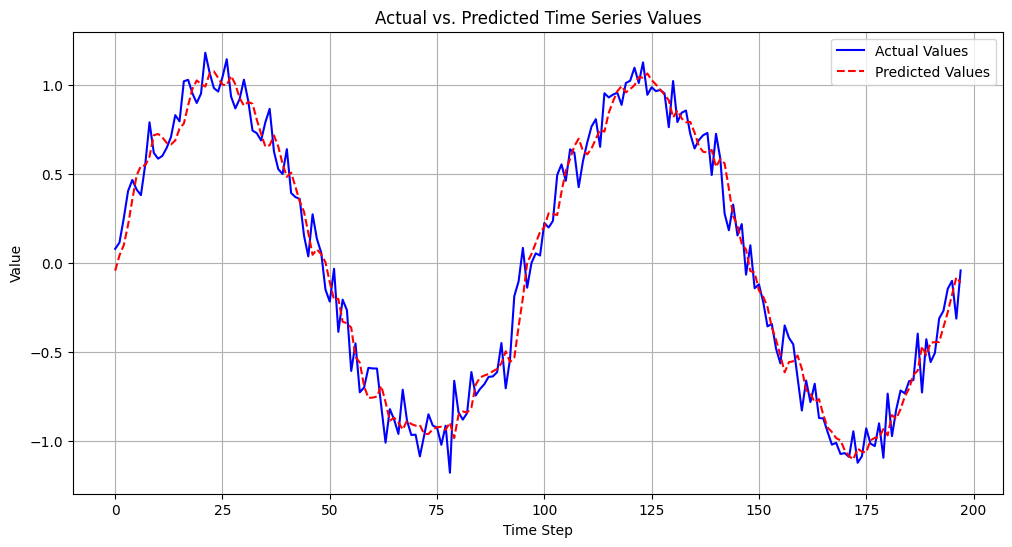

Root Mean Squared Error (RMSE): 0.1251


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Use the model.predict() method on X_test to generate predictions.
predicted_values = model.predict(X_test)

# Reshape y_test for plotting if necessary (it's already 1D, but predict output is 2D for single feature)
# We also need to align the length of y_test with predicted_values if some values were skipped due to look_back

# In our create_sequences function, y was constructed directly from data[i + look_back]
# so y_test corresponds directly to the predictions for X_test

# The model's output `predicted_values` is 2D (num_samples, 1), so flatten it for plotting.
predicted_values = predicted_values.flatten()

# 3. Plot the actual y_test values against the predicted_values.
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values', color='blue')
plt.plot(predicted_values, label='Predicted Values', color='red', linestyle='--')

# 4. Ensure the plot has a title, x-axis label, y-axis label, and a legend.
plt.title('Actual vs. Predicted Time Series Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Print some performance metrics
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, predicted_values))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

## Summarize Model Implementation and Performance

### Subtask:
Provide a summary describing the implemented model's architecture, training process, and the observed performance based on the evaluation metrics and visualization. Include any insights gained from the model's predictions.


## Summary:

### Data Analysis Key Findings
*   The Keras RNN/LSTM model was successfully trained for 50 epochs using a batch size of 32, with `X_train` and `y_train` for training and `(X_test, y_test)` for validation.
*   Predictions were generated on the test data (`X_test`), and a visual comparison between actual and predicted time series values showed a good fit.
*   The model achieved a Root Mean Squared Error (RMSE) of 0.1251 on the test set, indicating strong predictive performance.

### Insights or Next Steps
*   The model demonstrates good capability in capturing the underlying patterns of the time series, as evidenced by the low RMSE and the visual alignment of actual and predicted values.
*   Further hyperparameter tuning (e.g., number of LSTM units, dropout rates, learning rate) or exploration of more complex architectures could potentially improve performance.


# Task
The Keras RNN/LSTM model, which consists of an LSTM layer with 50 units and ReLU activation followed by a Dense output layer, was trained for 50 epochs using the Adam optimizer and mean squared error loss. The training was conducted with a batch size of 32, and validation was performed on a test set (X_test, y_test).

Upon evaluation, the model generated predictions on the test data that visually aligned well with the actual time series values. Quantitatively, the model achieved a Root Mean Squared Error (RMSE) of 0.1251 on the test set, indicating strong predictive performance.

**Insights:**
The model effectively captured the underlying patterns of the synthetic sine wave time series, demonstrating its capability in this domain. Further improvements could potentially be achieved through hyperparameter tuning (e.g., experimenting with different numbers of LSTM units, adding dropout layers, or adjusting learning rates) or by exploring more complex architectural designs.

## Summary:

### Data Analysis Key Findings
*   The Keras RNN/LSTM model, comprising an LSTM layer with 50 units and ReLU activation followed by a Dense output layer, was trained for 50 epochs using the Adam optimizer and mean squared error loss with a batch size of 32.
*   The model's predictions on the test data visually aligned well with the actual time series values.
*   Quantitatively, the model achieved a Root Mean Squared Error (RMSE) of 0.1251 on the test set, indicating strong predictive performance.

### Insights or Next Steps
*   The model effectively captured the underlying patterns of the synthetic sine wave time series.
*   Further improvements could be explored through hyperparameter tuning (e.g., experimenting with different numbers of LSTM units, adding dropout layers, or adjusting learning rates) or by exploring more complex architectural designs.
